# India vs New zealand T20 Score Prediction 

In [1]:
#Importing Libraries

import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

## Loading data in pandas DataFrame 

In [2]:
df = pd.read_csv(r"C:\Users\chara\Downloads\india_vs_newzealand_t20_wc_2026_synthetic_dataset.csv")

In [3]:
# printing the first 5 rows of dataset
df.head()

,match_id,venue,inning,batting_team,bowling_team,over,ball,batsman,bowler,runs_scored,wicket,total_runs,wickets_fallen,balls_bowled,balls_remaining,current_run_rate,powerplay
0,1,Ahmedabad,1,India,New Zealand,1,1,Virat Kohli,Trent Boult,0,0,0,0,1,119,0.00,1
1,1,Ahmedabad,1,India,New Zealand,1,2,Rohit Sharma,Trent Boult,1,0,1,0,2,118,0.50,1
2,1,Ahmedabad,1,India,New Zealand,1,3,Hardik Pandya,Trent Boult,6,0,7,0,3,117,2.33,1
3,1,Ahmedabad,1,India,New Zealand,1,4,Rohit Sharma,Trent Boult,0,0,7,0,4,116,1.75,1
4,1,Ahmedabad,1,India,New Zealand,1,5,Virat Kohli,Trent Boult,0,0,7,0,5,115,1.40,1


In [4]:
# printing the last 5 rows of dataset
df.tail()

,match_id,venue,inning,batting_team,bowling_team,over,ball,batsman,bowler,runs_scored,wicket,total_runs,wickets_fallen,balls_bowled,balls_remaining,current_run_rate,powerplay
235,1,Ahmedabad,2,New Zealand,India,20,2,Daryl Mitchell,Jasprit Bumrah,3,0,348,9,116,4,3.00,0
236,1,Ahmedabad,2,New Zealand,India,20,3,Rachin Ravindra,Jasprit Bumrah,2,0,350,9,117,3,2.99,0
237,1,Ahmedabad,2,New Zealand,India,20,4,Rachin Ravindra,Jasprit Bumrah,6,0,356,9,118,2,3.02,0
238,1,Ahmedabad,2,New Zealand,India,20,5,Kane Williamson,Jasprit Bumrah,0,0,356,9,119,1,2.99,0
239,1,Ahmedabad,2,New Zealand,India,20,6,Glenn Phillips,Jasprit Bumrah,0,0,356,9,120,0,2.97,0


In [5]:
# Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          240 non-null    int64  
 1   venue             240 non-null    object 
 2   inning            240 non-null    int64  
 3   batting_team      240 non-null    object 
 4   bowling_team      240 non-null    object 
 5   over              240 non-null    int64  
 6   ball              240 non-null    int64  
 7   batsman           240 non-null    object 
 8   bowler            240 non-null    object 
 9   runs_scored       240 non-null    int64  
 10  wicket            240 non-null    int64  
 11  total_runs        240 non-null    int64  
 12  wickets_fallen    240 non-null    int64  
 13  balls_bowled      240 non-null    int64  
 14  balls_remaining   240 non-null    int64  
 15  current_run_rate  240 non-null    float64
 16  powerplay         240 non-null    int64  
dt

In [6]:
# Checking the missing values in dataset
df.isnull().sum()

match_id            0
venue               0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
bowler              0
runs_scored         0
wicket              0
total_runs          0
wickets_fallen      0
balls_bowled        0
balls_remaining     0
current_run_rate    0
powerplay           0
dtype: int64

In [7]:
# Statistical measures
df.describe()

,match_id,inning,over,ball,runs_scored,wicket,total_runs,wickets_fallen,balls_bowled,balls_remaining,current_run_rate,powerplay
count,240.0,240.000000,240.000000,240.000000,240.000000,240.0000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,1.0,1.500000,10.500000,3.500000,2.800000,0.0500,171.375000,3.529167,60.500000,59.500000,2.788708,0.300000
std,0.0,0.501045,5.778332,1.711394,2.072332,0.2184,98.819692,3.217236,34.712206,34.712206,0.347052,0.459215
min,1.0,1.000000,1.000000,1.000000,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.0,1.000000,5.750000,2.000000,1.000000,0.0000,87.000000,1.000000,30.750000,29.750000,2.680000,0.000000
50%,1.0,1.500000,10.500000,3.500000,3.000000,0.0000,178.000000,2.000000,60.500000,59.500000,2.815000,0.000000
75%,1.0,2.000000,15.250000,5.000000,4.000000,0.0000,252.250000,6.000000,90.250000,89.250000,2.980000,1.000000
max,1.0,2.000000,20.000000,6.000000,6.000000,1.0000,356.000000,9.000000,120.000000,119.000000,4.000000,1.000000


## Exploratory Data Analysis

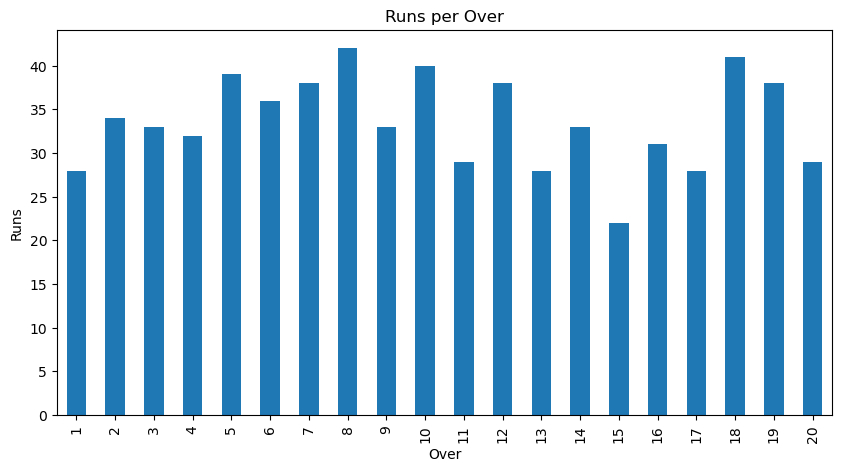

In [8]:
runs_per_over = df.groupby("over")["runs_scored"].sum()

plt.figure(figsize=(10,5))
runs_per_over.plot(kind="bar")
plt.title("Runs per Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

Here, is the total runs per over of 2 innings

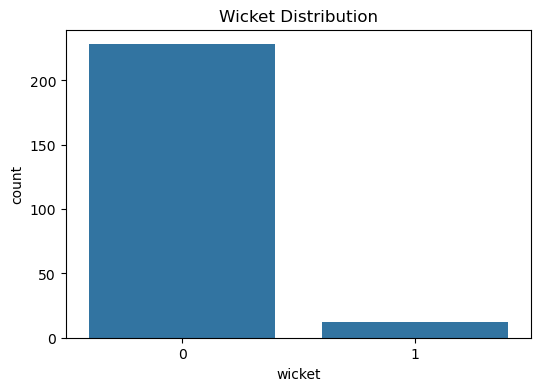

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="wicket", data=df)

plt.title("Wicket Distribution")
plt.show()

### 0 = no wicket

### 1 = wicket

Most balls do not result in wickets, so the distribution looks like:

wicket	  count

0	       ~220

1	       ~20

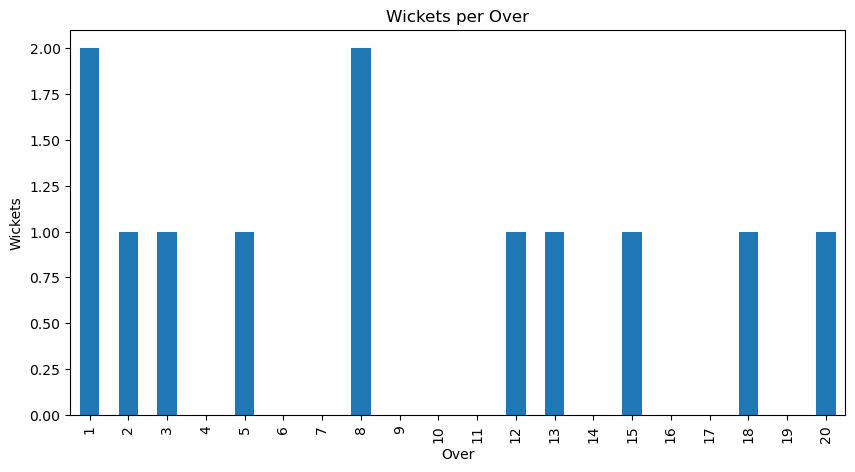

In [12]:
wickets_per_over = df.groupby("over")["wicket"].sum()

plt.figure(figsize=(10,5))
wickets_per_over.plot(kind="bar")

plt.title("Wickets per Over")
plt.xlabel("Over")
plt.ylabel("Wickets")
plt.show()

## Feature Selection 

In [16]:
X = df[[
    "over",
    "ball",
    "wickets_fallen",
    "balls_remaining",
    "current_run_rate"
]]

Y = df["total_runs"]

choosing the meaniningful features that can impact target variable

## Train Test Split

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 26)

In [18]:
print(X.shape, X_train.shape, X_test.shape)

(240, 5) (192, 5) (48, 5)


In [21]:
print(Y.shape, Y_train.shape, Y_test.shape)

(240,) (192,) (48,)


## Training the model

In [22]:
model = RandomForestRegressor()

model.fit(X_train, Y_train)

RandomForestRegressor()

## Make Prediction

In [23]:
predictions = model.predict(X_test)

predictions[:10]

array([ 92.86, 249.22, 257.74, 275.  , 270.01, 227.39, 332.14,  73.42,
        89.27, 135.24])

## Model Evaluation

In [25]:
mae = mean_absolute_error(Y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.640833333333332


The Random Forest Regressor achieved a Mean Absolute Error (MAE) of 2.64 runs, indicating that the predicted scores differ from the actual scores by approximately 2–3 runs on average. This demonstrates strong predictive performance for match score estimation.

In [32]:
## Prediction System 

sample = [[10, 2, 3, 60, 8]]

prediction = model.predict(sample)

print("Predicted Score:", round(prediction[0],2))

Predicted Score: 184.37


C:\Users\chara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
